In [3]:
# install reqd packages - code runs even though VS code shows squiglee
try:
    %load_ext autotime
except:
    !pip install ipython-autotime
    %load_ext autotime

try:
    %load_ext pulp
except:
    !pip install pulp

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/17.7 MB 4.8 MB/s eta 0:00:04
   ----- ---------------------------------- 2.4/17.7 MB 6.1 MB/s eta 0:00:03
   -------- ------------------------------- 3.7/17.7 MB 6.2 MB/s eta 0:00:03
   ----------- ---------------------------- 5.2/17.7 MB 6.4 MB/s eta 0:00:02
   -------------- ------------------------- 6.6/17.7 MB 6.4 MB/s eta 0:00:02
   ----------------- ---------------------- 7.9/17.7 MB 6.2 MB/s eta 0:00:02
   -------------------- ------------------- 9.2/17.7 MB 6.3 MB/s eta 0:00:02
   ------------------------ --------------- 10.7/17.7 MB 6.4 MB/s eta 0:00:02
   --------------------------- ------------ 12.1/17.7 MB 6.3 MB/s eta 0:00:01
   ------------------------------ --------- 13.4/17.7 MB 6.4 MB/s eta 0:0

Linear Programming
---------------------------------------------
In this module, we will study linear programming problems:

What is a linear programming problem?
Why are linear programming problems useful?
How do we model some important algorithmic problems as linear programs?
How do we solve linear programs?
    A short tutorial on solving LPs in Python with pointers to important software.
Finally, we will study a brief overview of algorithms for linear programming.
This module and the next one in this course are part of an important subject of mathematical optimization or mathematical programming. The programming here refers to an older notion that is closer to "scheduling" or "planning" rather than programming a computer.

Linear Programming (LP) Problems
----------------------------------------

Simple Example

Amy and George would like to split a cake between themselves. Here are the rules for their cake splitting.

Amy would like to have at least one-third of the cake (or more).
George would like to have at least one-fourth of the cake (or more).
George cannot have more than half the cake (he is on a diet).
Amy will donate  $10
  times her share of the cake to charity.
For example, if Amy receives  0.35
  share of the cake, she will provide  $3.50
  to charity.
George will donate  $20
  times his share of the cake to charity.
For example, if George receives  0.4
  share of the cake, he will donate  $8.00
  to charity.
We wish to find a way to split the full cake between Amy and George so that we maximize the money donated to charity while respecting the constraints above.


Intuitively this problem is easy to reason about: George pays a lot more than Amy. A greedy strategy is to give George as much cake as he can eat while respecting all the constraints. Following this, we conclude that the optimal solution is as follows:

George gets half the cake, and
Amy gets the remaining half.
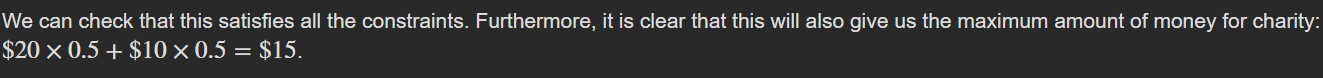

To make it precise and mathematical, let  𝑥
  denote Amy's share of the cake as a fraction of the entire cake and  𝑦
  denote George's share as a fraction of the entire cake.

𝑥,𝑦
  are called the decision variables for the problem. They represent real numbers and in this instance the fractions of cake given to Amy and George respectively.

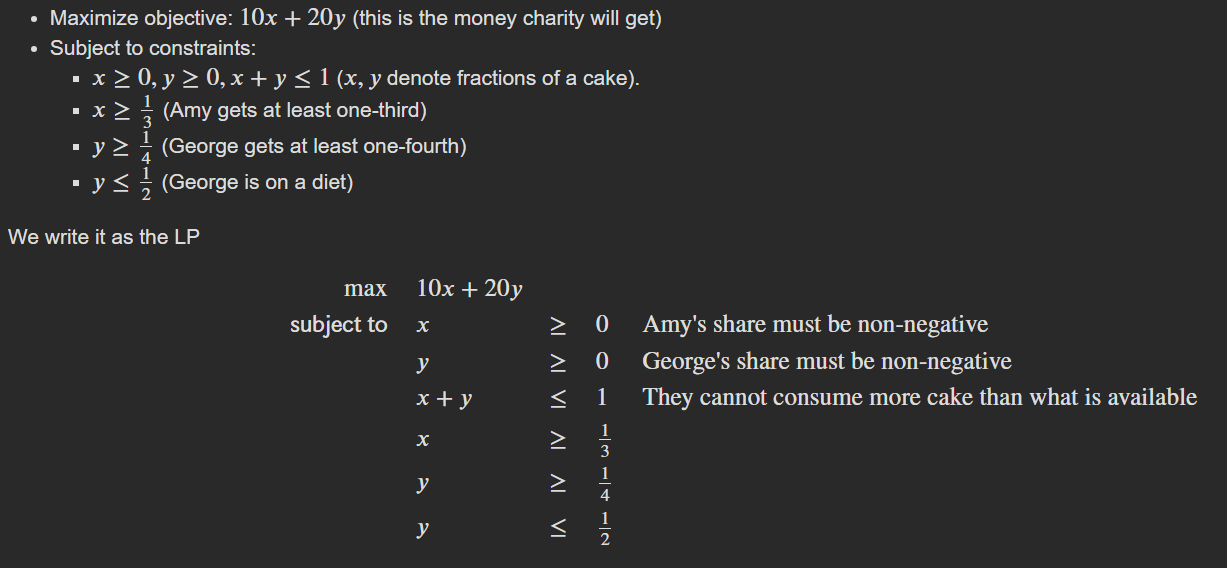

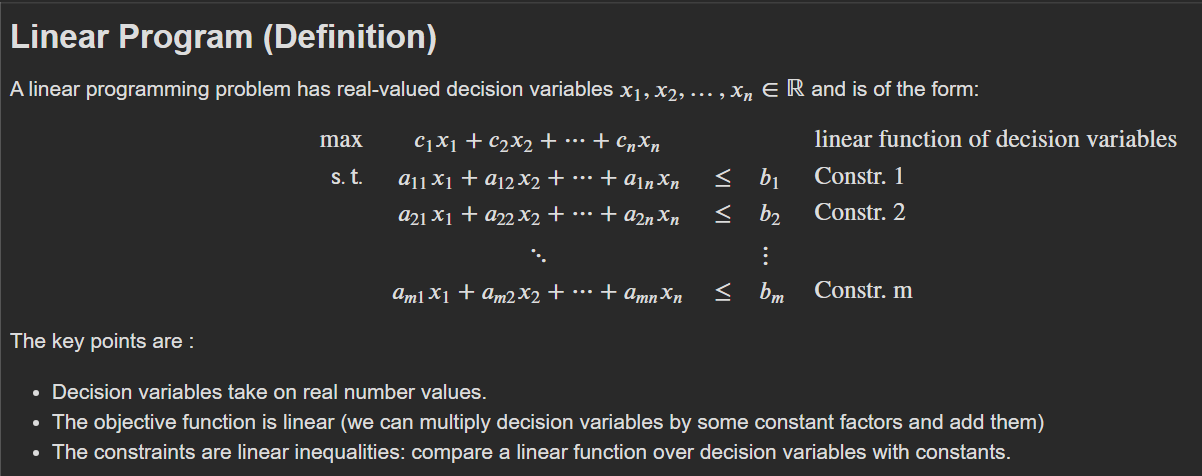




The key points are :

Decision variables take on real number values.
The objective function is linear (we can multiply decision variables by some constant factors and add them)
The constraints are linear inequalities: compare a linear function over decision variables with constants.
Linear Programming problems are very simple and even restrictive in scope. Nevertheless, they are one of the most widely used class of optimization problems and many algorithmic problems can be translated into a linear program. There are very efficient algorithms for solving LPs including the -
famous Simplex algorithm of Danzig and the 
interior point methods. 

We can solve LPs with millions of variables and constraints quite fast.

In [4]:
from pulp import * 
# pulp is a very nice python interface that can work with numerous LP solvers in the backend.
# It allows us a very simple and intuitive interface to write and solve LPs.
# Create the problem and specify that we are maximizing the objective
model = LpProblem("AmyGeorgeCakeCuttingProblem", LpMaximize)
x = LpVariable("AmyShare", 0.0, 1.0)
y = LpVariable("GeorgeShare", 0.0, 1.0) 
model += 10 * x + 20 * y # add the objective function to the model.
# adding the constraints.
model += x+y <=1 , "fractions sum up to less than eq to 1"
model += x >= 1/3, "Amy min share"
model += y >= 1/4, "George min share"
model += y <= 1/2, "George diet"
model.solve() # solve the problem
# Each of the variables is printed with it's resolved optimum value
for v in model.variables():
    print(v.name, "=", v.varValue)
print(f'Objective value - money obtained for charity: {value(model.objective)}')

AmyShare = 0.5
GeorgeShare = 0.5
Objective value - money obtained for charity: 15.0
time: 547 ms (started: 2024-10-18 20:43:10 -07:00)


Solving Linear Programs
Solving a linear program should ideally yield the optimal solution in the form of

The values given to each decision variable.
The overall value of the objective function. Thus, solving the LP for Amy and George's cake cutting problem, we obtain that  𝑥=0.5,𝑦=0.5
  is the optimal solution whose objective value is  15
 .
However, not every LP needs to have such an optimal solution. There are two special cases to be aware of.

Infeasible Problems
-------------------------------------- 
Sometimes a LP may be infeasible. This happens because the constraints are contradictory to each other and thus the problem has no solutions at all. Here is an example:

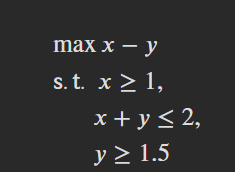

Unfortunately, if we insist that  𝑥≥1
  and  𝑦≥1.5
  the first and third constraints respectively, we already know that this implies  𝑥+𝑦≥2.5
  must hold. This directly contradicts the second constraint. Thus no solutions can be found to satisfy these constraints.

In [6]:
model = LpProblem("InfeasibleProblem", LpMaximize)
x = LpVariable("x", 1.0, None) # create x with lower limit x >= 1
y = LpVariable("y", 1.5, None) # create y with lower limit y >= 1.5
model += x-y
model += x+y <= 2
model.solve() # returns -1 linear relaxation infeasible

-1

time: 16 ms (started: 2024-10-19 07:08:03 -07:00)


Unbounded Problems
Even if a LP is feasible, it is possible that the optimal value can be unbounded. In other words, for a maximization problem one can obtain larger and larger solutions without a bound (or smaller and smaller solutions for minimization problems). Here is a simple example

max 𝑥+𝑦 𝗌.𝗍. 𝑥≥1, 𝑦≥0

Note that since there is no upper limit on  𝑥,𝑦  we have no limit on the solution.

In [8]:
model = LpProblem("UnboundedProblem", LpMaximize)
x = LpVariable("x", 1.0, None) # create x with lower limit x >= 1
y = LpVariable("y", 0.0, None) # create y with lower limit y >= 0
model += x+y
model.solve() # returns -2 Linear relaxation unbounded

-2

time: 31 ms (started: 2024-10-19 07:11:29 -07:00)


Solving LPs: Summary
------------------------------
Thus, an LP can have three possible solutions.

Optimal: We have an optimal solution  𝑥∗1,…,𝑥∗𝑛
  that achieves the "best" value of the objective function.
Infeasible: The constraints do not have any solutions (they are mutually contradictory).
Unbounded: There is no bound on the optimal solution.

Variants/Extensions of Linear Programming
------------------------------
We can extend our definition of LP in a few trivial but useful ways:

Equality constraints: LPs can accomodate constraints of the form 𝑎1𝑥1+⋯+𝑎𝑛𝑥𝑛=𝑏
 --------
since an equality constraint of the form  𝑓=0
  is a combination of two inequality constraints  𝑓≥0
  and  𝑓≤0.

Minimization of objective instead of maximizing.
-------
 If we wish to minimize an objective  𝑐1𝑥1+⋯+𝑐𝑛𝑥𝑛
 , we may instead maximize its negation  −𝑐1𝑥1−𝑐2𝑥2−⋯−𝑐𝑛𝑥𝑛
  (just remember to flip the sign of your answer).

  Following extensions are not allowed
  ---------------------------
Nonlinear objective functions or constraints will change the nature of the problem and they are no longer linear programs. Example:
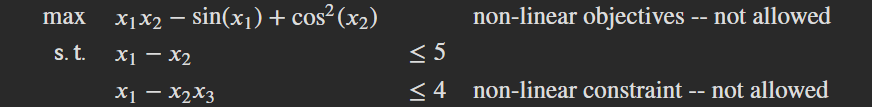

The constraints are implicitly "and"-ed together. In other words, all the constraints have to be satisfied. If you have two constraints where you want either one constraint to hold or another but not necessarily both, that changes the nature of the problem completely and it is no longer a linear program.

Integer Linear Programming
The decision variables are real-numbers. They can take on values like  1.3331555
  or  𝜋
 . If the decision variables can only take on whole number values, that changes the nature of the problem to something called an integer linear program that we will study next week.